In [1]:

from utils import *

df = pd.read_csv("Experiment/3_hTERT_HME1_mutants_comparison/Data/Processed/Mutant_cell_lines_test.tsv", sep="\t")
df

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,WT_log2:FC_EGF_10,WT_log2:FC_EGF_25,BRAFS151A_log2:FC_EGF_starve,BRAFS151A_log2:FC_EGF_2,BRAFS151A_log2:FC_EGF_10,BRAFS151A_log2:FC_EGF_25,GAB1Y259A_log2:FC_EGF_starve,GAB1Y259A_log2:FC_EGF_2,GAB1Y259A_log2:FC_EGF_10,GAB1Y259A_log2:FC_EGF_25
0,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAASAGGKEAAS[79.9663]GPNDS[79.9663],455,484,30,2,"25S(79.9663),30S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGK,AAAAAAAAAAAAAAAAS[79.9663]AGGK,455,475,21,2,17S(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAAS[79.9663]AGGKEAAS[79.9663]GPNDS,455,484,30,2,"17S(79.9663),25S(79.9663)",...,NaN,NaN,0.0,NaN,1.888218,NaN,0.0,2.985974,NaN,2.937885
3,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSARQK,AAAAAAAAAAAPPAPPEGASPGDSARQK,1345,1372,28,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSAR,AAAAAAAAAAAPPAPPEGAS[79.9663]PGDS[79.9663]AR,1345,1370,26,2,"20S(79.9663),24S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175084,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQMDYYGTR,2,27,26,3,"N-term(42.0106),14M(15.9949)",...,0.444736,0.413445,0.0,-1.338201,-1.002712,-1.289534,0.0,-0.961074,-0.582581,-0.980391
175085,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQM[15.994...,2,27,26,3,"N-term(42.0106),14M(15.9949),20M(15.9949)",...,NaN,NaN,0.0,0.170052,NaN,NaN,0.0,0.063073,0.151763,-0.751698
175086,rev_Q17R98,rev_ZNF827,Zinc finger protein 827,WQGSNLGGTPVTHCK,n[42.0106]WQGSNLGGTPVTHC[57.0215]K,2,16,15,2,"N-term(42.0106),14C(57.0215)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175087,Q9NRJ4,TULP4,Tubby-related protein 4,YAAVEHGPVLCSDSNILCLSWK,n[42.0106]YAAVEHGPVLC[57.0215]S[79.9663]DSNILC...,2,23,22,2,"N-term(42.0106),11C(57.0215),12S(79.9663),18C(...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Filtering data

In [2]:
# Remove rows without PTM
df_filtered = df[df.Assigned_Modifications_clean.notna()]
print(f"Original size: {df.shape}")

# Drop rows where site is not detected in the starvation control
df_filtered = df_filtered[df_filtered["WT_raw:abs_EGF_starve_r1"] != 0]
df_filtered = df_filtered[df_filtered["BRAFS151A_raw:abs_EGF_starve_r1"] != 0]
df_filtered = df_filtered[df_filtered["GAB1Y259A_raw:abs_EGF_starve_r1"] != 0]

raw_columns = [element for element in df.columns if 'raw' in element]

print(f"Dataframe after removing sites with no starve detected: {df_filtered.shape}")
replicates = [element for element in raw_columns if "starve" not in element]
# print(f"Raw columns of time points replicates: {replicates}")

replicates = list(set([element.replace("_r1", "").replace("_r2", "") for element in replicates]))

suffixes = ["_r1", "_r2"]

# Drop rows if the phosphosite was not detected in the 2 replicates for any time point and any condition
for condition in replicates:
    mask = (
        (df_filtered[f"{condition}{suffixes[0]}"] == 0) &
        (df_filtered[f"{condition}{suffixes[1]}"] == 0)
    )
    df_filtered = df_filtered.drop(df_filtered[mask].index)

print(f"Dataframe after removing sites where a site is missing in the two replivates: {df_filtered.shape}")

df_filtered = filter_dynamics_extremes_mutants(df = df_filtered,
                                       data_type="log2:FC",
                                       threshold=0.5,
                                       exclude_full = False,
                                       conditions = ["_EGF_"],
                                       cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],)
print(f"Dataframe after selecting log2:FC > 0.5: {df_filtered.shape}")

Original size: (175089, 136)
Dataframe after removing sites with no starve detected: (13474, 136)
Dataframe after removing sites where a site is missing in the two replivates: (10885, 136)
Dataframe after selecting log2:FC > 0.5: (9561, 136)


# Clustering based on WT

In [3]:
cluster_name = "testing_clustering"
kmeans_clustered, clustering, multivariate = tslearn_clustering_KMeans_mutants(df_to_cluster= df_filtered,
                                                 data_type= "log2:FC",
                                                 cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],
                                                 condition_for_clustering=["_EGF_"],
                                                 exclude_full=True,
                                                 cluster_column_name=cluster_name,
                                                 number_of_clusters=25, #25
                                                 max_iterations=100,
                                                 metric="euclidean",
                                                 df_dimensions=3,
                                                 time_series_length=4,
                                                 transpose = True, #data size is (ns, sz, d)
                                                 verbose=True,
                                                 testing = True,
                                                 barycenter_calculations= False)

(9561, 136)
Column selection: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_25', 'BRAFS151A_log2:FC_EGF_starve', 'BRAFS151A_log2:FC_EGF_2', 'BRAFS151A_log2:FC_EGF_10', 'BRAFS151A_log2:FC_EGF_25', 'GAB1Y259A_log2:FC_EGF_starve', 'GAB1Y259A_log2:FC_EGF_2', 'GAB1Y259A_log2:FC_EGF_10', 'GAB1Y259A_log2:FC_EGF_25']

Reshaping dataframe to shape (9561, 4, 3)

The size of the dataset is (9561, 4, 3)
Example:
[[ 0.          0.          0.        ]
 [-0.09866993  0.88832203 -0.95591811]
 [-0.80844889  0.80315561  0.01617743]
 [-0.17997857  0.13015663  0.1793945 ]]
Init 1
3.048 --> 2.666 --> 2.594 --> 2.561 --> 2.533 --> 2.516 --> 2.508 --> 2.503 --> 2.498 --> 2.495 --> 2.493 --> 2.491 --> 2.489 --> 2.488 --> 2.487 --> 2.486 --> 2.485 --> 2.484 --> 2.483 --> 2.481 --> 2.480 --> 2.479 --> 2.478 --> 2.478 --> 2.477 --> 2.477 --> 2.477 --> 2.477 --> 2.477 --> 2.477 --> 2.476 --> 2.476 --> 2.476 --> 2.476 --> 2.476 --> 2.476 --> 2.476 --> 2.475 --> 2.475 --> 2.475

## plotting clusters

Exx Plot not saved


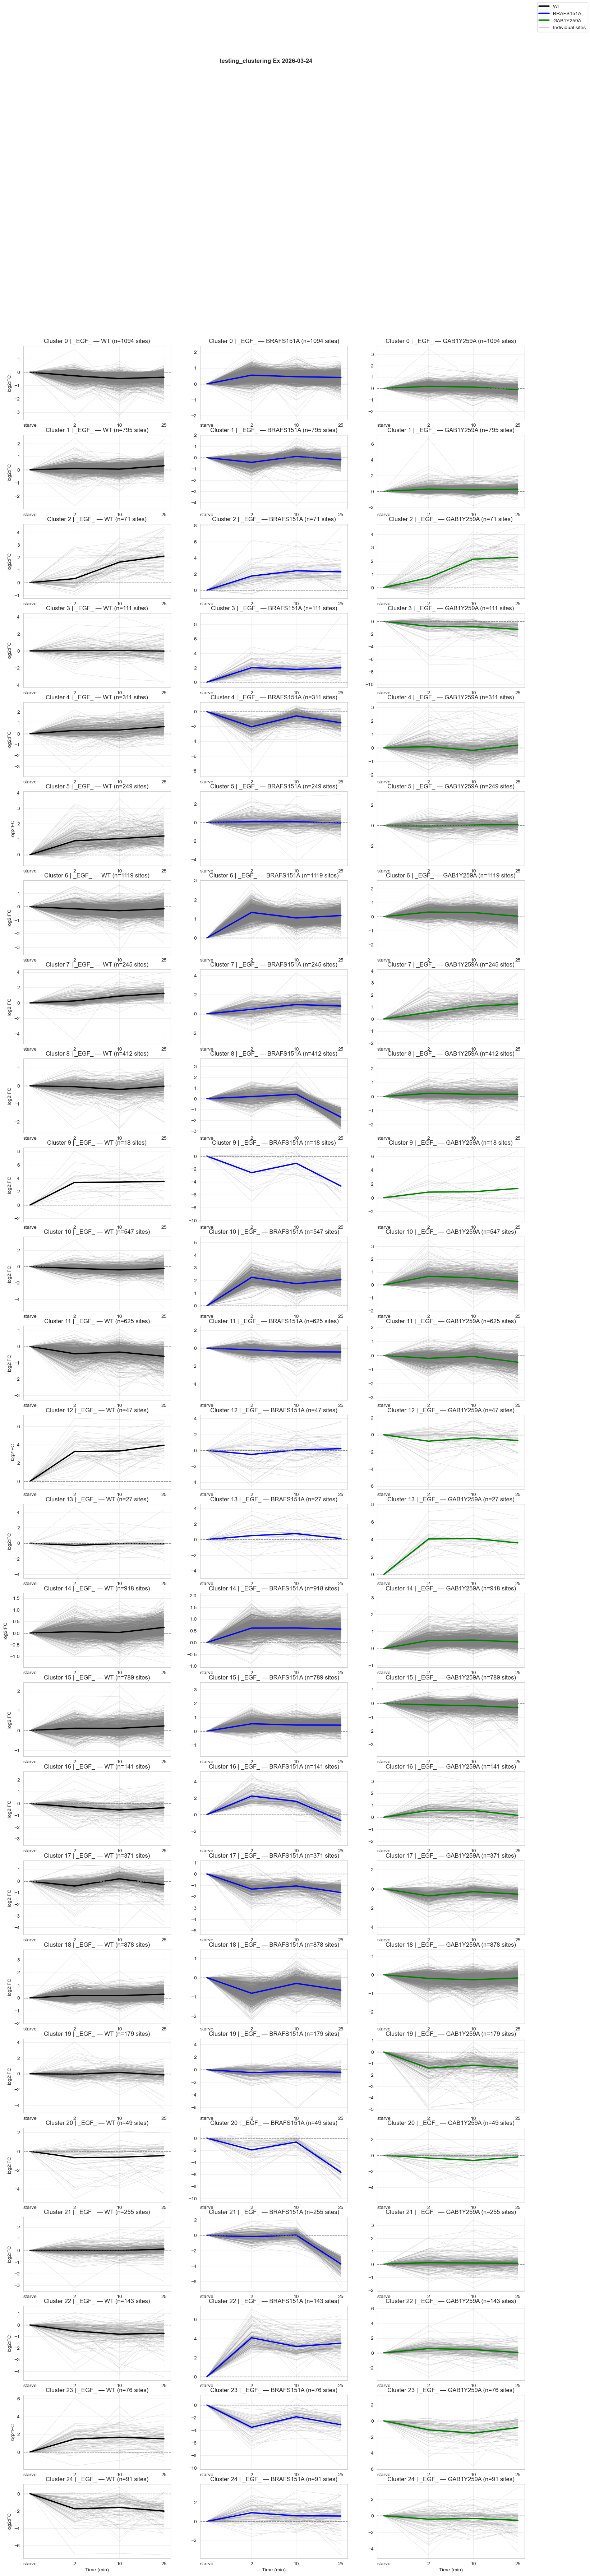

In [4]:
clusters_plot_linear_mutants(
        df = kmeans_clustered,
        legend=["1.57nM EGF", "100nM INS", "1.56nM EGF + 100nM INS"],
        saving_path="",
        cluster_column=cluster_name,
        cluster_name=f"Ex",
        data_type="log2:FC",
        same_cell_lines=False,
        same_condition = True,
        cell_lines= ["WT", "BRAFS151A", "GAB1Y259A"],
        conditions = ["_EGF_"],
        colors={"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"},
        plot_different_data=True,
        saving_info="x",
        save_pdf=False,
        save_png=False,
        plot_close=False,
        y_lims_list=False,
        grey_alpha=0.2,
        grey_lw=0.8,
        mean_lw=2.6
    )

## Check wich proteins are in a cluster

In [5]:
sub_df = kmeans_clustered.loc[kmeans_clustered[cluster_name] == 13]
protein_list = sub_df["protein_name"].unique().tolist()
uniprot_links_for(sub_df, protein_list)

## Check in which clusters a protein appear

In [6]:
protein = "EGFR"
protein_df = kmeans_clustered.loc[kmeans_clustered["protein_name"] == protein]
# protein_df = df.loc[df["protein_name"] == protein]
protein_df[["protein_name", "site", cluster_name]]

,protein_name,site,testing_clustering
29638,EGFR,P00533_687_705_1_1_False_T693,2
46656,EGFR,P00533_109_129_1_0_False_M111,18
49049,EGFR,P00533_1161_1179_1_1_False_Y1172,7
49050,EGFR,P00533_1161_1179_1_1_False_S1166,14
49546,EGFR,P00533_1189_1199_1_1_False_Y1197,7
89746,EGFR,P00533_987_999_1_1_False_S991,10


## Plotting all sites of a protein

Plotting sites of protein: RANBP1
RANBP1_P43487_log2:FC_ — plot not saved


/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/utils.py:2880: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


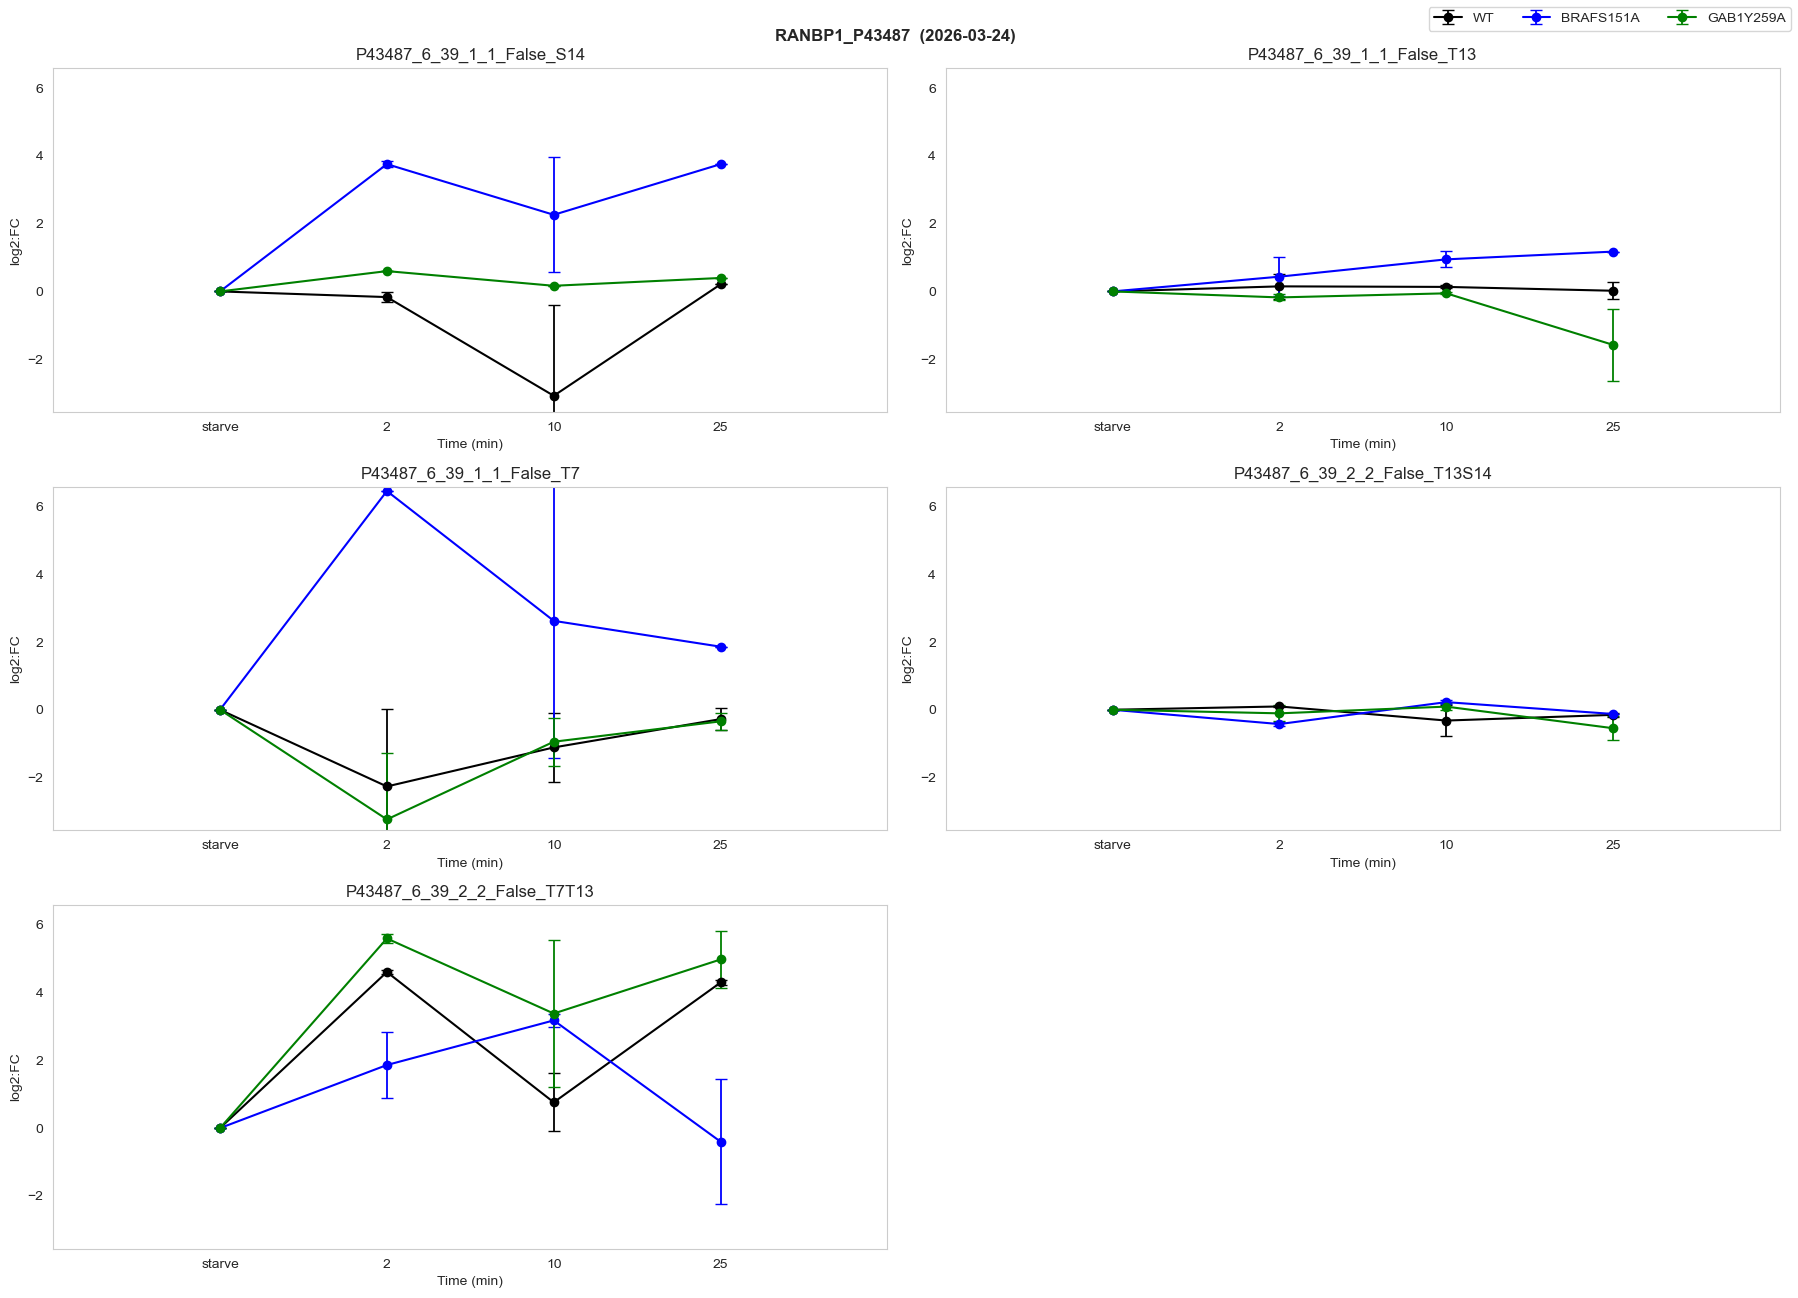

In [7]:
plot_mutants_protein_phosphosites(df = kmeans_clustered,
                                   proteins=["RANBP1"],
                                   data_type= "log2:FC",
                                   saving_path = "",
                                   legend_plot=["WT", "BRAFS151A", "GAB1Y259A"],
                                   cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],
                                   conditions = ["_EGF_"],
                                   color_palette = {"WT" : "black",
                                                 "BRAFS151A" : "blue",
                                                 "GAB1Y259A" : "green"},
                                   fit_y_lims= False
                     )

# Dimentionality reduction

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

import seaborn as sns

# Plotting functions
def get_color(sample_name):
    if sample_name.startswith('WT'):
        return 'black'
    elif sample_name.startswith('BRAF'):
        return 'blue'
    elif sample_name.startswith('GAB1'):
        return 'green'
    else:
        return 'gray'  # fallback

def plot_embedding(coords_df, x_col, y_col, title, colors, explained=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(coords_df[x_col], coords_df[y_col],
               c=colors, s=80, edgecolors='white', linewidths=0.5)
    for sample, color in zip(coords_df.index, colors):
        ax.annotate(sample, (coords_df.loc[sample, x_col], coords_df.loc[sample, y_col]),
                    fontsize=8, color=color, ha='left', va='bottom')
    xlabel = f'{x_col} ({explained[0]:.1f}%)' if explained else x_col
    ylabel = f'{y_col} ({explained[1]:.1f}%)' if explained else y_col
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    legend_elements = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='black', label='WT', markersize=8),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='blue', label='BRAF', markersize=8),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='green', label='GAB1', markersize=8),
    ]
    ax.legend(handles=legend_elements)
    plt.tight_layout(); plt.show()

In [30]:
# Select columns for the dimesionality reduction
columns = df_filtered.columns.to_list()
selected_columns = [col for col in columns if "log2:abs" in col]

sub_df = df_filtered[selected_columns]

# Transpose the dataframe. For the dimensionality reduction we want to apply it on the samples, in this case our samples are the time points and the detected phosphorylation sites are the features detected of the samples. This is why we have to transpose the matrix, puting the time points as rows (samples) and the sites as columns (features)
df_t = sub_df.T

# Deal with missing values, we can remove all columns with missing vaues, replace the missing values with "0", or impute the missing values based on the others
# I should be imputing based on the values of the replicate, not based on the whole column (all samples)
# for condition in replicates:
#     for suf in suffixes:
#         print(f"{condition}{suf}")
df_t = df_t.fillna(df_t.min().min())  # or use imputation

# For dimensionality reduction it is important to scale the data
scaler = StandardScaler()
scaled = scaler.fit_transform(df_t)
# scaled

## PCA

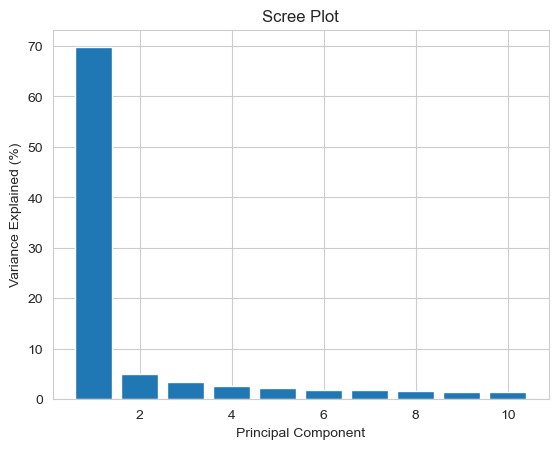

In [31]:
# PCA
pca = PCA(n_components=10)
pcs = pca.fit_transform(scaled)


explained = pca.explained_variance_ratio_ * 100
pc_df = pd.DataFrame(pcs, index=df_t.index,
                     columns=[f'PC{i+1}' for i in range(pcs.shape[1])])

colors = [get_color(s) for s in pc_df.index]

plt.bar(range(1, len(explained)+1), explained)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot')
plt.show()

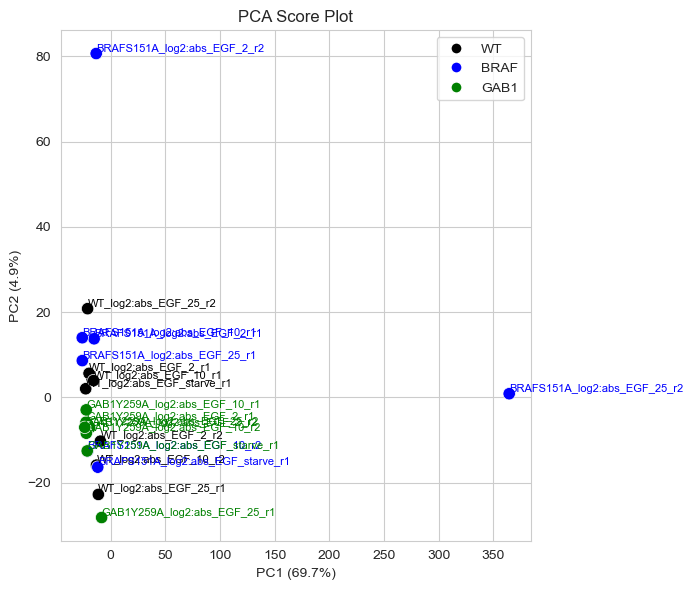

In [32]:
# plot_embedding(pc_df,   'PC1',   'PC2',   'PCA',   colors, explained)
# --- Score plot ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pc_df['PC1'], pc_df['PC2'], c=colors, s=80, edgecolors='white', linewidths=0.5)

for sample, color in zip(pc_df.index, colors):
    ax.annotate(sample, (pc_df.loc[sample, 'PC1'], pc_df.loc[sample, 'PC2']),
                fontsize=8, color=color, ha='left', va='bottom')

# Manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', label='WT', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='BRAF', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='GAB1', markersize=8),
]
ax.legend(handles=legend_elements)
ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)')
ax.set_title('PCA Score Plot')
plt.tight_layout()
plt.show()
# plot_embedding(pc_df, 'PC1', 'PC2', 'PCA',  colors)


## UMAP

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


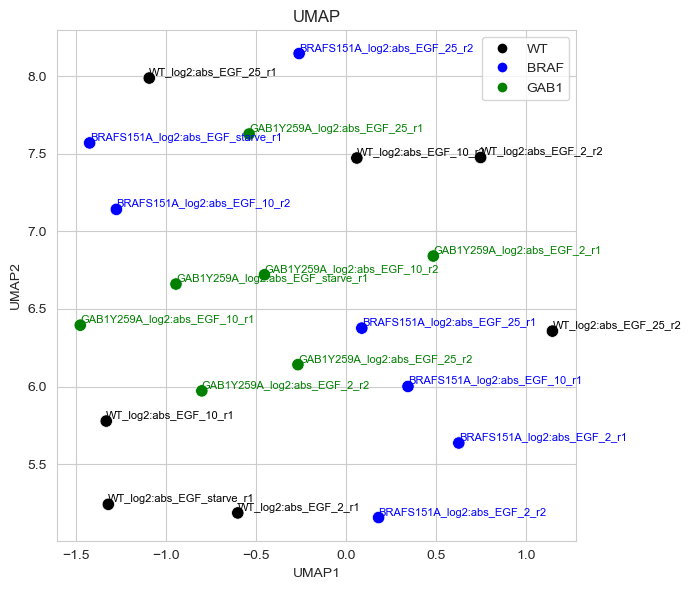

In [34]:
# UMAP
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,     # key param: low = local structure, high = global structure
    min_dist=0.1,       # how tightly points cluster (0.0–1.0)
    random_state=0
)
umap_coords = reducer.fit_transform(scaled) # scaled

umap_df = pd.DataFrame(umap_coords, index=df_t.index, columns=['UMAP1', 'UMAP2'])

plot_embedding(umap_df, 'UMAP1', 'UMAP2', 'UMAP',  colors)

# Similarity with TMT dataset

In [13]:
TMT_dataset = pd.read_csv("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus_new_naming.tsv", sep='\t')
LFQ_dataset = df_filtered.copy()

## Create column for both dataset with same naming method

In [14]:
TMT_dataset["new_site"] = TMT_dataset["site"].str.split("~").str[0]
TMT_dataset["new_site"] = (TMT_dataset["new_site"].str.split("_").str[0] + "_" + TMT_dataset["new_site"].str.split("_").str[-1])
# TMT_dataset["new_site"]

LFQ_dataset["new_site"] = LFQ_dataset["site"].str.replace("_True", "").replace("_False", "")
LFQ_dataset["new_site"] = LFQ_dataset["new_site"].str.replace("_False", "")
LFQ_dataset["new_site"] = (LFQ_dataset["new_site"].str.split("_").str[0] + "_" + LFQ_dataset["new_site"].str.split("_").str[-1])
# LFQ_dataset["new_site"]

## Select time points to use, and create sub df with them + filtering for redundancy in sites

In [15]:
columns = LFQ_dataset.columns
data_type = "log2:FC"
cell_line = ["WT"]
condition = ["_EGF_"]
times = [2, 10]

time_series = [element for element in columns if element.startswith(cell_line[0])
               and data_type in element
               and condition[0] in element
               ]
print(time_series)
time_series.remove("WT_log2:FC_EGF_25")
print(time_series)

['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_25']
['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10']


In [16]:
TMT_sites_list = list(TMT_dataset["new_site"].to_list())
LFQ_sites_list = list(LFQ_dataset["new_site"].to_list())

# Remove sites with more than one count (creates un-paring)
TMT_sites_1_count = [element for element in TMT_sites_list if TMT_sites_list.count(element) == 1]
LFQ_sites_1_count = [element for element in LFQ_sites_list if LFQ_sites_list.count(element) == 1]

common_sites = [site for site in TMT_sites_1_count if site in LFQ_sites_1_count]
print(len(common_sites))
print([common_sites[:10]])

3494
[['A0A2R8Y4L2_S312', 'A0A2R8Y4L2_S313', 'A0A3B3IU46_S36', 'A0FGR8_S691', 'A0FGR8_S693', 'A0FGR8_S755', 'A0FGR8_S761', 'A0FGR8_S755S758S761', 'A0JNW5_S418', 'A0MZ66_T537']]


In [17]:
TMT_dataset.set_index("new_site", drop= False, inplace=True)
TMT_sub_df = TMT_dataset.loc[TMT_dataset["new_site"].isin(common_sites)]
TMT_sub_df = TMT_sub_df[time_series]

LFQ_dataset.set_index("new_site", drop = False,  inplace=True)
LFQ_sub_df = LFQ_dataset.loc[LFQ_dataset["new_site"].isin(common_sites)]
LFQ_sub_df = LFQ_sub_df[time_series]
print(TMT_sub_df.shape, LFQ_sub_df.shape)

TMT_sub_df.sort_index()
LFQ_sub_df.sort_index()

(3494, 3) (3494, 3)


,WT_log2:FC_EGF_starve,WT_log2:FC_EGF_2,WT_log2:FC_EGF_10
new_site,,,
A0A2R8Y4L2_S312,0.0,0.450134,0.578473
A0A2R8Y4L2_S313,0.0,0.706490,0.035908
A0A3B3IU46_S36,0.0,-0.043535,-0.461190
A0FGR8_S691,0.0,0.416992,0.628323
A0FGR8_S693,0.0,-0.507518,-0.540744
...,...,...,...
Q9Y6X4_S378S379,0.0,-0.357974,-0.094400
Q9Y6X4_S526,0.0,-0.209452,-0.104974
Q9Y6X9_S615,0.0,-0.107838,-0.517106


## Calculate euclidean distances. Representation

In [18]:
# calculate euclidena distances
diff = TMT_sub_df - LFQ_sub_df
euclidean_distances = np.sqrt(np.sum(diff ** 2, axis=1))

distances = pd.Series(euclidean_distances, index=common_sites, name="euclidean_distance")

print(f"\nEuclidean distance summary:")
print(distances.describe().round(3))

# Percentile thresholds — useful for defining agreement categories later
p25, p50, p75, p90 = np.percentile(euclidean_distances, [25, 50, 75, 90])
print(f"\n  25th percentile : {p25:.3f}")
print(f"  50th percentile : {p50:.3f}")
print(f"  75th percentile : {p75:.3f}")
print(f"  90th percentile : {p90:.3f}")

# =============================================================================
# NULL DISTRIBUTION — distances from randomly shuffled site pairs
# =============================================================================
n_sites = len(common_sites)

rng = np.random.default_rng(seed=42)
n_permutations = n_sites                                 # same number as real distances

shuffled_idx = rng.permutation(n_sites)
# Pair each TMT profile with a random LFQ profile from a different site
lfq_shuffled = LFQ_sub_df.values[shuffled_idx]
diff_null = TMT_sub_df.values - lfq_shuffled
null_distances = np.sqrt(np.sum(diff_null ** 2, axis=1))


Euclidean distance summary:
count    3494.000
mean        0.636
std         0.686
min         0.007
25%         0.278
50%         0.469
75%         0.756
max         9.899
Name: euclidean_distance, dtype: float64

  25th percentile : 0.278
  50th percentile : 0.469
  75th percentile : 0.756
  90th percentile : 1.167


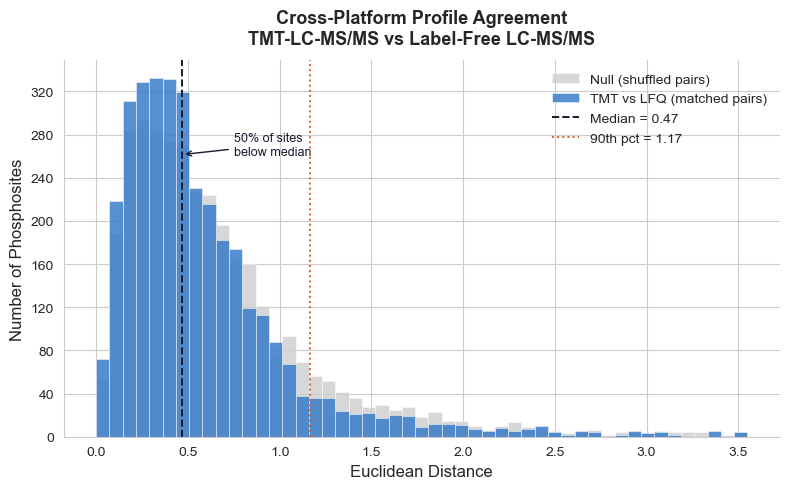

In [19]:
# =============================================================================
# HISTOGRAM
# =============================================================================
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 5))

# Choose bin edges shared across both distributions for a fair visual comparison
all_values = np.concatenate([euclidean_distances, null_distances])
bins = np.linspace(0, np.percentile(all_values, 99), 50)

ax.hist(null_distances, bins=bins, color="#d0d0d0", edgecolor="white",
        linewidth=0.4, alpha=0.85, label="Null (shuffled pairs)", zorder=2)

ax.hist(euclidean_distances, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.85, label="TMT vs LFQ (matched pairs)", zorder=3)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="--", linewidth=1.4,
           label=f"Median = {p50:.2f}", zorder=4)

# 90th percentile line
ax.axvline(p90, color="#e05c2a", linestyle=":", linewidth=1.4,
           label=f"90th pct = {p90:.2f}", zorder=4)

# Labels and formatting
ax.set_xlabel("Euclidean Distance", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_title("Cross-Platform Profile Agreement\nTMT-LC-MS/MS vs Label-Free LC-MS/MS",
             fontsize=13, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Annotation: % of sites below median as a quick reproducibility read
pct_below_median = np.mean(euclidean_distances <= p50) * 100
ax.annotate(f"{pct_below_median:.0f}% of sites\nbelow median",
            xy=(p50, ax.get_ylim()[1] * 0.75),
            xytext=(p50 + (bins[-1] * 0.08), ax.get_ylim()[1] * 0.75),
            fontsize=9, color="#1a1a2e",
            arrowprops=dict(arrowstyle="->", color="#1a1a2e", lw=1.0))

plt.tight_layout()
# plt.savefig("euclidean_distance_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
# print("\nPlot saved to euclidean_distance_histogram.png")

In [20]:
# import matplotlib.lines as mlines
#
# mean_tmt = TMT_sub_df.mean(axis=1).rename("mean_intensity_tmt")
# mean_lfq = LFQ_sub_df.mean(axis=1).rename("mean_intensity_lfq")
#
# # =============================================================================
# # TERCILE ASSIGNMENT
# # =============================================================================
#
# tercile_cutoffs = np.percentile(euclidean_distances, [33.3, 66.6])
#
# def assign_tercile(d):
#     if d <= tercile_cutoffs[0]:
#         return "Low distance\n(high agreement)"
#     elif d <= tercile_cutoffs[1]:
#         return "Mid distance\n(moderate agreement)"
#     else:
#         return "High distance\n(low agreement)"
#
# tercile_labels = distances.map(assign_tercile)
#
# TERCILE_ORDER  = ["Low distance\n(high agreement)",
#                   "Mid distance\n(moderate agreement)",
#                   "High distance\n(low agreement)"]
# TERCILE_COLORS = {
#     "Low distance\n(high agreement)"   : "#3A7DC9",   # blue
#     "Mid distance\n(moderate agreement)": "#F0A500",   # amber
#     "High distance\n(low agreement)"   : "#D7382A",   # red
# }
#
# # =============================================================================
# # BUILD PLOTTING DATAFRAME
# # Reshape so each site contributes TWO points (one per platform) with the
# # same y-value (distance) but different x-values (mean intensity per platform)
# # =============================================================================
#
# df_tmt = pd.DataFrame({
#     "mean_intensity" : mean_tmt,
#     "distance"       : distances,
#     "tercile"        : tercile_labels,
#     "platform"       : "TMT",
# })
#
# df_lfq = pd.DataFrame({
#     "mean_intensity" : mean_lfq,
#     "distance"       : distances,
#     "tercile"        : tercile_labels,
#     "platform"       : "LFQ",
# })
#
# plot_df = pd.concat([df_tmt, df_lfq])
#
# # =============================================================================
# # SCATTER PLOT — two panels side by side, one per platform
# # =============================================================================
#
# fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#
# MARKERS = {"TMT": "o", "LFQ": "s"}
# platforms = ["TMT", "LFQ"]
# panel_titles = ["TMT-LC-MS/MS", "Label-Free LC-MS/MS"]
#
# for ax, platform, title in zip(axes, platforms, panel_titles):
#     sub = plot_df[plot_df["platform"] == platform]
#
#     for tercile in TERCILE_ORDER:
#         mask = sub["tercile"] == tercile
#         ax.scatter(
#             sub.loc[mask, "mean_intensity"],
#             sub.loc[mask, "distance"],
#             c=TERCILE_COLORS[tercile],
#             marker=MARKERS[platform],
#             s=18,
#             alpha=0.65,
#             linewidths=0,
#             label=tercile,
#             zorder=3,
#         )
#
#     # Tercile cutoff lines (horizontal — same y reference in both panels)
#     for cutoff, ls in zip(tercile_cutoffs, ["--", ":"]):
#         ax.axhline(cutoff, color="#555555", linewidth=0.9, linestyle=ls, zorder=2)
#
#     ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
#     ax.set_xlabel("Mean Normalized Intensity", fontsize=11)
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)
#
# axes[0].set_ylabel("Euclidean Distance", fontsize=11)
#
# # Cutoff line annotations on the right panel only
# ax_right = axes[1]
# x_ann = ax_right.get_xlim()[1] if ax_right.get_xlim()[1] != 1.0 else plot_df[plot_df["platform"]=="LFQ"]["mean_intensity"].max()
# for cutoff, label in zip(tercile_cutoffs, ["33rd pct", "67th pct"]):
#     ax_right.annotate(
#         label,
#         xy=(ax_right.get_xlim()[0], cutoff),
#         xytext=(4, 3),
#         textcoords="offset points",
#         fontsize=8,
#         color="#555555",
#     )
#
# # Shared legend — tercile colors
# legend_handles = [
#     mlines.Line2D([], [], marker="o", color="w", markerfacecolor=TERCILE_COLORS[t],
#                   markersize=8, label=t.replace("\n", " "))
#     for t in TERCILE_ORDER
# ]
# fig.legend(
#     handles=legend_handles,
#     title="Distance Tercile",
#     title_fontsize=10,
#     fontsize=9,
#     loc="lower center",
#     ncol=3,
#     frameon=False,
#     bbox_to_anchor=(0.5, -0.12),
# )
#
# fig.suptitle("Euclidean Distance vs Mean Intensity per Platform",
#              fontsize=13, fontweight="bold", y=1.02)
#
# plt.tight_layout()
# # plt.savefig("distance_vs_intensity_scatter.png", dpi=150, bbox_inches="tight")
# plt.show()
# # print("Plot saved to distance_vs_intensity_scatter.png")


## Checking pearson correlation


Pearson r summary:
count    3494.000
mean        0.141
std         0.723
min        -1.000
25%        -0.579
50%         0.286
75%         0.860
max         1.000
Name: pearson_r, dtype: float64

  Median r               : 0.286
  % sites r >= 0.90      : 21.8%
  % sites r >= 0.75      : 32.3%
  % sites r <  0.00      : 41.6%  (opposite direction)


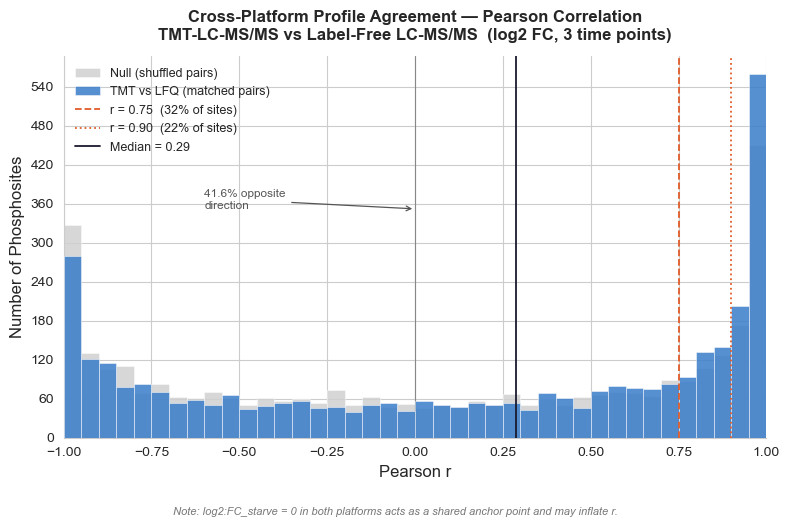

In [21]:
import matplotlib.ticker as ticker
from scipy import stats

# =============================================================================
# PEARSON CORRELATION — one r value per phosphosite
# scipy.stats.pearsonr returns (r, p-value) per site
# =============================================================================

results = []
for site in common_sites:
    r, pval = stats.pearsonr(TMT_sub_df.loc[site], LFQ_sub_df.loc[site])
    results.append({"site": site, "pearson_r": r, "pval": pval})

results_df = pd.DataFrame(results).set_index("site")
# results_df.to_csv("pearson_correlations.csv")

pearson_r = results_df["pearson_r"].values

# Summary
print(f"\nPearson r summary:")
print(results_df["pearson_r"].describe().round(3))

p25, p50, p75 = np.percentile(pearson_r, [25, 50, 75])
pct_above_09  = np.mean(pearson_r >= 0.9)  * 100
pct_above_075 = np.mean(pearson_r >= 0.75) * 100
pct_below_0   = np.mean(pearson_r <  0.0)  * 100

print(f"\n  Median r               : {p50:.3f}")
print(f"  % sites r >= 0.90      : {pct_above_09:.1f}%")
print(f"  % sites r >= 0.75      : {pct_above_075:.1f}%")
print(f"  % sites r <  0.00      : {pct_below_0:.1f}%  (opposite direction)")

# =============================================================================
# NULL DISTRIBUTION — shuffle LFQ site pairing
# =============================================================================

rng = np.random.default_rng(seed=42)
n_sites      = len(common_sites)
shuffled_idx = rng.permutation(n_sites)
lfq_shuffled = LFQ_sub_df.values[shuffled_idx]

null_r = []
for i in range(n_sites):
    r_null, _ = stats.pearsonr(LFQ_sub_df.values[i], lfq_shuffled[i])
    null_r.append(r_null)
null_r = np.array(null_r)

# =============================================================================
# HISTOGRAM
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(-1, 1, 41)   # fixed range for Pearson r

ax.hist(null_r, bins=bins, color="#d0d0d0", edgecolor="white",
        linewidth=0.4, alpha=0.85, label="Null (shuffled pairs)", zorder=2)

ax.hist(pearson_r, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.85, label="TMT vs LFQ (matched pairs)", zorder=3)

# Reference lines
for thresh, label, ls in zip(
    [0.75, 0.90],
    ["r = 0.75", "r = 0.90"],
    ["--",       ":"]
):
    ax.axvline(thresh, color="#e05c2a", linestyle=ls, linewidth=1.3,
               label=f"{label}  ({np.mean(pearson_r >= thresh)*100:.0f}% of sites)", zorder=4)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="-", linewidth=1.3,
           label=f"Median = {p50:.2f}", zorder=4)

# Opposite-direction annotation
if pct_below_0 > 0:
    ax.axvline(0, color="#888888", linestyle="-", linewidth=0.8, zorder=2)
    ax.annotate(f"{pct_below_0:.1f}% opposite\ndirection",
                xy=(0, ax.get_ylim()[1] * 0.6),
                xytext=(-0.6, ax.get_ylim()[1] * 0.6),
                fontsize=8.5, color="#555555",
                arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9))

ax.set_xlabel("Pearson r", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_xlim(-1, 1)
ax.set_title("Cross-Platform Profile Agreement — Pearson Correlation\n"
             "TMT-LC-MS/MS vs Label-Free LC-MS/MS  (log2 FC, 3 time points)",
             fontsize=12, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Caveat footnote
fig.text(0.5, -0.04,
         "Note: log2:FC_starve = 0 in both platforms acts as a shared anchor point and may inflate r.",
         ha="center", fontsize=8, color="#777777", style="italic")

plt.tight_layout()
# plt.savefig("pearson_correlation_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Plot saved to pearson_correlation_histogram.png")


## Repeat similarity calculation on dataset where log2:FC > 0.5

### Filtration

In [22]:
LFQ = filter_dynamics_extremes_mutants(
    df = LFQ_dataset,
    data_type="log2:FC",
    threshold=0.5,
    exclude_full = True,
    conditions = ["_EGF_"],
    cell_lines = ["WT"],
)

mask = TMT_dataset[time_series].abs().max(axis=1) >= 0.5
TMT = TMT_dataset.loc[mask].copy()
print(LFQ.shape, TMT.shape)

(5514, 138) (4522, 482)


### Create column for both dataset with common name

In [23]:
TMT["new_site"] = TMT["site"].str.split("~").str[0]
TMT["new_site"] = (TMT["new_site"].str.split("_").str[0] + "_" + TMT["new_site"].str.split("_").str[-1])

LFQ["new_site"] = LFQ["site"].str.replace("_True", "").replace("_False", "")
LFQ["new_site"] = LFQ["new_site"].str.replace("_False", "")
LFQ["new_site"] = (LFQ["new_site"].str.split("_").str[0] + "_" + LFQ["new_site"].str.split("_").str[-1])

### Select time points to use and filter redundancy

In [24]:
columns = LFQ.columns
data_type = "log2:FC"
cell_line = ["WT"]
condition = ["_EGF_"]
times = [2, 10]

time_series = [element for element in columns if element.startswith(cell_line[0])
               and data_type in element
               and condition[0] in element
               ]
print(time_series)
time_series.remove("WT_log2:FC_EGF_25")
print(time_series)

['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_25']
['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10']


In [25]:
TMT_sites_list = list(TMT["new_site"].to_list())
LFQ_sites_list = list(LFQ["new_site"].to_list())

# Remove sites with more than one count (creates un-paring)
TMT_sites_1_count = [element for element in TMT_sites_list if TMT_sites_list.count(element) == 1]
LFQ_sites_1_count = [element for element in LFQ_sites_list if LFQ_sites_list.count(element) == 1]

common_sites = [site for site in TMT_sites_1_count if site in LFQ_sites_1_count]
print(len(common_sites))
print([common_sites[:10]])

264
[['A1L390_S1037', 'O00459_S263', 'O00515_S356', 'O14497_S363', 'O14686_S2274', 'O14950_T19S20', 'O15446_S136', 'O43399_S166', 'O43768_S67', 'O60271_T217']]


In [26]:
TMT.set_index("new_site", drop= False, inplace=True)
TMT_sub_df_05 = TMT.loc[TMT["new_site"].isin(common_sites)]
TMT_sub_df_05 = TMT_sub_df_05[time_series]

LFQ.set_index("new_site", drop = False,  inplace=True)
LFQ_sub_df_05 = LFQ.loc[LFQ["new_site"].isin(common_sites)]
LFQ_sub_df_05 = LFQ_sub_df_05[time_series]
print(TMT_sub_df_05.shape, LFQ_sub_df_05.shape)

TMT_sub_df_05.sort_index()
LFQ_sub_df_05.sort_index()

(264, 3) (264, 3)


,WT_log2:FC_EGF_starve,WT_log2:FC_EGF_2,WT_log2:FC_EGF_10
new_site,,,
A1L390_S1037,0.0,0.068571,0.698941
O00459_S263,0.0,0.654772,0.978787
O00515_S356,0.0,-0.218086,0.267980
O14497_S363,0.0,-0.218218,-0.521541
O14686_S2274,0.0,0.321471,1.545434
...,...,...,...
Q9Y6I3_S435,0.0,-0.106522,0.411811
Q9Y6I3_S454,0.0,-0.011135,0.995295
Q9Y6M7_T1167,0.0,-0.541672,-0.080299


### Calculate euclidean distances. Representation

In [27]:
# calculate euclidena distances
diff = TMT_sub_df_05 - LFQ_sub_df_05
euclidean_distances = np.sqrt(np.sum(diff ** 2, axis=1))

distances = pd.Series(euclidean_distances, index=common_sites, name="euclidean_distance")

print(f"\nEuclidean distance summary:")
print(distances.describe().round(3))

# Percentile thresholds — useful for defining agreement categories later
p25, p50, p75, p90 = np.percentile(euclidean_distances, [25, 50, 75, 90])
print(f"\n  25th percentile : {p25:.3f}")
print(f"  50th percentile : {p50:.3f}")
print(f"  75th percentile : {p75:.3f}")
print(f"  90th percentile : {p90:.3f}")

# =============================================================================
# NULL DISTRIBUTION — distances from randomly shuffled site pairs
# =============================================================================
n_sites = len(common_sites)

rng = np.random.default_rng(seed=42)
n_permutations = n_sites                                 # same number as real distances

shuffled_idx = rng.permutation(n_sites)
# Pair each TMT profile with a random LFQ profile from a different site
lfq_shuffled = LFQ_sub_df_05.values[shuffled_idx]
diff_null = TMT_sub_df_05.values - lfq_shuffled
null_distances = np.sqrt(np.sum(diff_null ** 2, axis=1))


Euclidean distance summary:
count    264.000
mean       0.721
std        0.642
min        0.023
25%        0.314
50%        0.525
75%        0.877
max        4.043
Name: euclidean_distance, dtype: float64

  25th percentile : 0.314
  50th percentile : 0.525
  75th percentile : 0.877
  90th percentile : 1.544


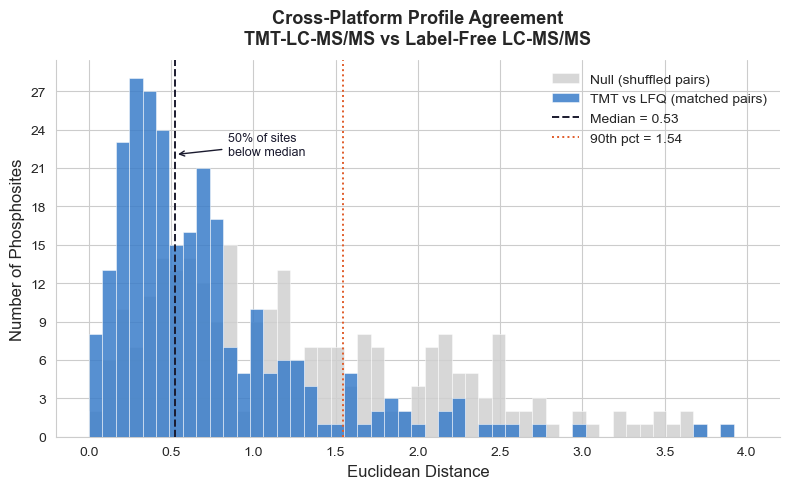

In [28]:
# =============================================================================
# HISTOGRAM
# =============================================================================
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 5))

# Choose bin edges shared across both distributions for a fair visual comparison
all_values = np.concatenate([euclidean_distances, null_distances])
bins = np.linspace(0, np.percentile(all_values, 99), 50)

ax.hist(null_distances, bins=bins, color="#d0d0d0", edgecolor="white",
        linewidth=0.4, alpha=0.85, label="Null (shuffled pairs)", zorder=2)

ax.hist(euclidean_distances, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.85, label="TMT vs LFQ (matched pairs)", zorder=3)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="--", linewidth=1.4,
           label=f"Median = {p50:.2f}", zorder=4)

# 90th percentile line
ax.axvline(p90, color="#e05c2a", linestyle=":", linewidth=1.4,
           label=f"90th pct = {p90:.2f}", zorder=4)

# Labels and formatting
ax.set_xlabel("Euclidean Distance", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_title("Cross-Platform Profile Agreement\nTMT-LC-MS/MS vs Label-Free LC-MS/MS",
             fontsize=13, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Annotation: % of sites below median as a quick reproducibility read
pct_below_median = np.mean(euclidean_distances <= p50) * 100
ax.annotate(f"{pct_below_median:.0f}% of sites\nbelow median",
            xy=(p50, ax.get_ylim()[1] * 0.75),
            xytext=(p50 + (bins[-1] * 0.08), ax.get_ylim()[1] * 0.75),
            fontsize=9, color="#1a1a2e",
            arrowprops=dict(arrowstyle="->", color="#1a1a2e", lw=1.0))

plt.tight_layout()
# plt.savefig("euclidean_distance_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
# print("\nPlot saved to euclidean_distance_histogram.png")

### Checking pearson correlation


Pearson r summary:
count    264.000
mean       0.712
std        0.566
min       -0.998
25%        0.856
50%        0.960
75%        0.992
max        1.000
Name: pearson_r, dtype: float64

  Median r               : 0.960
  % sites r >= 0.90      : 67.0%
  % sites r >= 0.75      : 80.3%
  % sites r <  0.00      : 12.5%  (opposite direction)


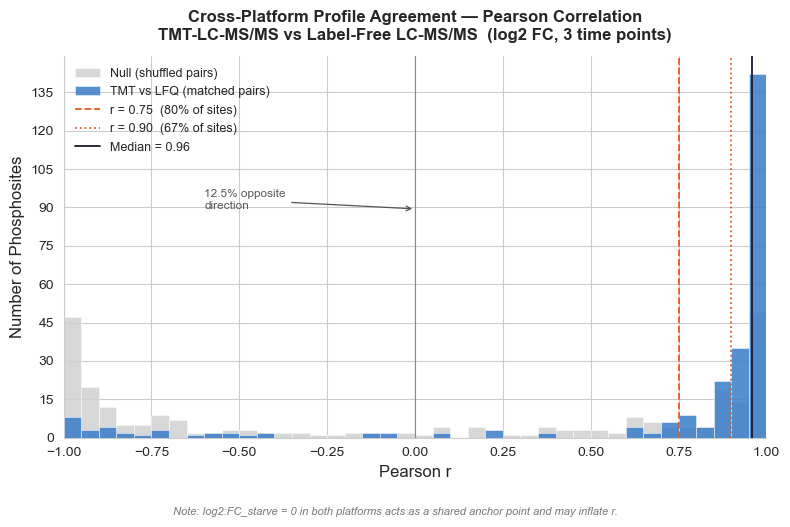

In [29]:
import matplotlib.ticker as ticker
from scipy import stats

# =============================================================================
# PEARSON CORRELATION — one r value per phosphosite
# scipy.stats.pearsonr returns (r, p-value) per site
# =============================================================================

results = []
for site in common_sites:
    r, pval = stats.pearsonr(TMT_sub_df_05.loc[site], LFQ_sub_df_05.loc[site])
    results.append({"site": site, "pearson_r": r, "pval": pval})

results_df = pd.DataFrame(results).set_index("site")
# results_df.to_csv("pearson_correlations.csv")

pearson_r = results_df["pearson_r"].values

# Summary
print(f"\nPearson r summary:")
print(results_df["pearson_r"].describe().round(3))

p25, p50, p75 = np.percentile(pearson_r, [25, 50, 75])
pct_above_09  = np.mean(pearson_r >= 0.9)  * 100
pct_above_075 = np.mean(pearson_r >= 0.75) * 100
pct_below_0   = np.mean(pearson_r <  0.0)  * 100

print(f"\n  Median r               : {p50:.3f}")
print(f"  % sites r >= 0.90      : {pct_above_09:.1f}%")
print(f"  % sites r >= 0.75      : {pct_above_075:.1f}%")
print(f"  % sites r <  0.00      : {pct_below_0:.1f}%  (opposite direction)")

# =============================================================================
# NULL DISTRIBUTION — shuffle LFQ site pairing
# =============================================================================

rng = np.random.default_rng(seed=42)
n_sites      = len(common_sites)
shuffled_idx = rng.permutation(n_sites)
lfq_shuffled = LFQ_sub_df_05.values[shuffled_idx]

null_r = []
for i in range(n_sites):
    r_null, _ = stats.pearsonr(LFQ_sub_df_05.values[i], lfq_shuffled[i])
    null_r.append(r_null)
null_r = np.array(null_r)

# =============================================================================
# HISTOGRAM
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(-1, 1, 41)   # fixed range for Pearson r

ax.hist(null_r, bins=bins, color="#d0d0d0", edgecolor="white",
        linewidth=0.4, alpha=0.85, label="Null (shuffled pairs)", zorder=2)

ax.hist(pearson_r, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.85, label="TMT vs LFQ (matched pairs)", zorder=3)

# Reference lines
for thresh, label, ls in zip(
    [0.75, 0.90],
    ["r = 0.75", "r = 0.90"],
    ["--",       ":"]
):
    ax.axvline(thresh, color="#e05c2a", linestyle=ls, linewidth=1.3,
               label=f"{label}  ({np.mean(pearson_r >= thresh)*100:.0f}% of sites)", zorder=4)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="-", linewidth=1.3,
           label=f"Median = {p50:.2f}", zorder=4)

# Opposite-direction annotation
if pct_below_0 > 0:
    ax.axvline(0, color="#888888", linestyle="-", linewidth=0.8, zorder=2)
    ax.annotate(f"{pct_below_0:.1f}% opposite\ndirection",
                xy=(0, ax.get_ylim()[1] * 0.6),
                xytext=(-0.6, ax.get_ylim()[1] * 0.6),
                fontsize=8.5, color="#555555",
                arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9))

ax.set_xlabel("Pearson r", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_xlim(-1, 1)
ax.set_title("Cross-Platform Profile Agreement — Pearson Correlation\n"
             "TMT-LC-MS/MS vs Label-Free LC-MS/MS  (log2 FC, 3 time points)",
             fontsize=12, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Caveat footnote
fig.text(0.5, -0.04,
         "Note: log2:FC_starve = 0 in both platforms acts as a shared anchor point and may inflate r.",
         ha="center", fontsize=8, color="#777777", style="italic")

plt.tight_layout()
# plt.savefig("pearson_correlation_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Plot saved to pearson_correlation_histogram.png")
